In [1]:
import matplotlib.pyplot as plt
import numpy as np
import configparser
from scipy import stats
import pandas as pd
from sklearn.metrics import roc_curve, auc

In [2]:
#pmt details
!curl -O https://raw.githubusercontent.com/XENON1T/pax/refs/heads/master/pax/config/XENON1T.ini
config = configparser.ConfigParser()
config.read('XENON1T.ini')
pmt_config = eval(config['DEFAULT']['pmts'])
pmt_positions = np.array([(x['position']['x'], x['position']['y'])
                           for x in pmt_config if x.get('array', '') == 'top'])
tpc_radius = 47.9

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100 303.3k 100 303.3k   0      0 959.9k      0                              0
100 303.3k 100 303.3k   0      0 959.2k      0                              0
100 303.3k 100 303.3k   0      0 958.6k      0                              0


In [3]:
def mean_response(xy):
    """Return normalized mean response of PMTs to light emission at xy"""
    a = -2.7e-5
    b = 3.6e-3
    i0 = 0.290
    d = 12.13
    p = 2.35
    # Compute distance from xy to pmt position
    # xy has shape (positions, 2)
    # pmt_positions has shape (pmts, 2)
    # Output should have shape (positions, pmts)
    rho = np.linalg.norm(xy[:, None, :] - pmt_positions[None, :, :], axis=2)
    raw_lce = i0 * (1-b) / (1 + (rho/d)**2)**p + a * rho + b
    # Normalize to 1
    return raw_lce / np.sum(raw_lce, axis=1)[:, None]

def simulate_signal(xy, photons=10_000):
    """Simulate a signal where an average number of photons are detected by PMTs at xy"""
    lce = mean_response(xy)
    # Random photon detection
    photons_detected = np.random.poisson(photons * lce)
    # Double photoelectron emission
    pe_detected = photons_detected + np.random.binomial(photons_detected, 0.2)
    # Gaussian smearing
    return np.random.normal(pe_detected, 0.3 * np.sqrt(pe_detected))

def simulate_uniform_signals(num_signals=1000, photons=10_000):
    """Simulate signals uniformly distributed in the TPC"""
    angles = np.random.uniform(0, 2*np.pi, num_signals)
    radii = np.sqrt(np.random.uniform(0, tpc_radius**2, num_signals))
    xy = np.column_stack((radii * np.cos(angles), radii * np.sin(angles)))
    return simulate_signal(xy, photons), xy

def simulate_uniform_double_signals(num_signals=1000, photons=10_000):
    """Simulate double scatters that are uniformly distributed"""
    angle1 = np.random.uniform(0, 2*np.pi, num_signals)
    radius1 = np.sqrt(np.random.uniform(0, tpc_radius**2, num_signals))
    xy1 = np.column_stack((radius1 * np.cos(angle1), radius1 * np.sin(angle1)))
    angle2 = np.random.uniform(0, 2*np.pi, num_signals)
    radius2 = np.sqrt(np.random.uniform(0, tpc_radius**2, num_signals))
    xy2 = np.column_stack((radius2 * np.cos(angle2), radius2 * np.sin(angle2)))
    signal1 = simulate_signal(xy1, photons)
    signal2 = simulate_signal(xy2, photons)
    return signal1 + signal2, xy1, xy2

def simulate_double_signal_constrained_parameters(num_signals=1000, photons=10_000, distance=10, ratio=0.5):
    """Simulate a double scatter signal with a fixed distance and a fixed signal ratio between the signals"""
    
    signal1 = []
    signal2 = []
    true_xy1 = []
    true_xy2 = []
    while len(signal1) < num_signals:
        angle1 = np.random.uniform(0, 2*np.pi)
        radius1 = np.sqrt(np.random.uniform(0, (tpc_radius)**2))
        xy1 = np.column_stack((radius1 * np.cos(angle1), radius1 * np.sin(angle1)))
        angle2 = np.random.uniform(0, 2*np.pi)
        xy2 = xy1 + np.column_stack((distance * np.cos(angle2), distance * np.sin(angle2)))
        # Accept if xy2 is withing TPC
        if np.linalg.norm(xy2, axis=1) < tpc_radius:
            signal1.append(simulate_signal(xy1, ratio * photons).squeeze())      # (127,)
            signal2.append(simulate_signal(xy2, (1-ratio) * photons).squeeze())
            true_xy1.append(xy1.squeeze())
            true_xy2.append(xy2.squeeze())
    return np.array(signal1) + np.array(signal2), np.array(true_xy1), np.array(true_xy2), ratio

Single scatter hypothesis model and optimization

In [4]:
# Define loss function for single scatter hypothesis
def loss_function(xy, signal):
    """Negative log-likelihood of observing signal given mean response at xy. The log likelihood is defined as the sum of the log of the Poisson probabilities for each PMT, given the expected signal from the mean response at xy."""
    lce = mean_response(xy.reshape(1, 2)).squeeze()
    expected_signal = 10_000 * lce  # Assuming 10k photons emitted
    # Poisson likelihood
    return -np.sum(signal * np.log(expected_signal + 1e-6) - expected_signal)

# Define single scatter optimizer
from scipy.optimize import minimize
# Single scatter optimizer
def single_scatter_optimizer(signal):
    """Optimizes parameters for single scatter hypothesis,
    taking the highest valued pmt as initial guess and
    then running a local optimizer"""

    pmt_high=np.argmax(signal)
    initial_guess = pmt_positions[pmt_high]
    result = minimize(lambda xy: loss_function(xy, signal), initial_guess, bounds=[(-tpc_radius, tpc_radius), (-tpc_radius, tpc_radius)])
    return result.x

Double scatter hypothesis model and optimization

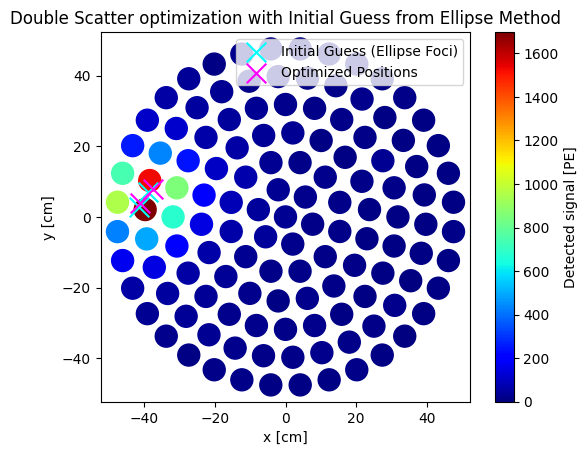

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -58461.351508951964
        x: [-4.105e+01  4.075e+00 -3.758e+01  7.784e+00  5.408e-01]
      nit: 25
      jac: [ 0.000e+00 -2.183e-03  2.910e-03 -2.183e-03  2.110e-02]
     nfev: 180
     njev: 30
 hess_inv: <5x5 LbfgsInvHessProduct with dtype=float64>

In [20]:
#double scatter optimizer
def true_parameter_guess(signal, xy1, xy2, ratio):
    initial_guess = np.array([xy1[0][0], xy1[0][1], xy2[0][0], xy2[0][1], ratio])
    return (initial_guess, xy1[0], xy2[0], 
            (xy1[0] + xy2[0]) / 2, 
            np.linalg.norm(xy1[0] - xy2[0]) / 2, 
            np.linalg.norm(xy1[0] - xy2[0]) / 2, 
            np.degrees(np.arctan2(xy2[0][1] - xy1[0][1], xy2[0][0] - xy1[0][0])))

def top_PMT_initial_guess(signal):
    """Simple initial guess for double scatter hypothesis, takes 2 highest valued PMTs
    and uses their positiosn as initial guess for two scatters.
    Signal ratio is estimated from signal ratio of 2 strongest PMTs."""
    # Find the indices of the two highest valued PMTs
    top_indices = np.argsort(signal)[-2:]
    # Estimate signal ratio from the two strongest PMTs
    split_ratio = signal[top_indices[0]] / (signal[top_indices[0]] + signal[top_indices[1]])
    # Use their positions as initial guess for the two scatters
    initial_guess = [pmt_positions[top_indices[0], 0], pmt_positions[top_indices[0], 1],
                     pmt_positions[top_indices[1], 0], pmt_positions[top_indices[1], 1], split_ratio]  # x1, y1, x2, y2, split ratio
    return initial_guess

def double_scatter_loss(params, signal):
    """Loss function for double scatter hypothesis, given parameters and observed signal. The parameters are x1, y1, x2, y2, and split ratio of the signal between the two scatters."""
    x1, y1, x2, y2, split_ratio = params
    xy1 = np.array([[x1, y1]])
    xy2 = np.array([[x2, y2]])
    expected_signal1 = 10_000 * mean_response(xy1).squeeze() * split_ratio
    expected_signal2 = 10_000 * mean_response(xy2).squeeze() * (1 - split_ratio)
    expected_signal = expected_signal1 + expected_signal2
    return -np.sum(signal * np.log(expected_signal + 1e-6) - expected_signal)

def double_scatter_optimizer(signal, xy1=None, xy2=None, ratio=None):
    """Optimizes parameters for double scatter hypothesis, using the initial guess from the ellipse method."""
    if xy1 is None or xy2 is None or ratio is None:
        initial_guess = top_PMT_initial_guess(signal)
    else:
        initial_guess, focus1, focus2, center, a, b, angle_deg = true_parameter_guess(signal, xy1, xy2, ratio)
    bounds = [(-tpc_radius, tpc_radius), (-tpc_radius, tpc_radius), (-tpc_radius, tpc_radius), (-tpc_radius, tpc_radius), (0.01, 0.99)]
    result = minimize(lambda params: double_scatter_loss(params, signal), initial_guess, bounds=bounds)
    return result

def double_scatter_optimizer_with_plotting(signal, xy1=None, xy2=None, ratio=None):
    """Optimizes parameters for double scatter hypothesis, using the initial guess from the ellipse method."""
    initial_guess, focus1, focus2, center, a, b, angle_deg = true_parameter_guess(signal, xy1, xy2, ratio)
    bounds = [(-tpc_radius, tpc_radius), (-tpc_radius, tpc_radius), (-tpc_radius, tpc_radius), (-tpc_radius, tpc_radius), (0.01, 0.99)]
    result = minimize(lambda params: double_scatter_loss(params, signal), initial_guess, bounds=bounds)
    plt.scatter(*pmt_positions.T, c=signal, cmap='jet', s=250, vmin=0)
    plt.colorbar(label='Detected signal [PE]')
    plt.scatter([initial_guess[0], initial_guess[2]], [initial_guess[1], initial_guess[3]], c='cyan', marker='x', s=200, label='Initial Guess (Ellipse Foci)')
    plt.scatter([result.x[0], result.x[2]], [result.x[1], result.x[3]], c='magenta', marker='x', s=200, label='Optimized Positions')
    plt.legend()
    plt.gca().set_aspect('equal')
    plt.xlabel('x [cm]')
    plt.ylabel('y [cm]')

    plt.title('Double Scatter optimization with Initial Guess from Ellipse Method')
    plt.show()
    
    return result
#double_scatter_optimizer_with_plotting(simulate_uniform_double_signals(num_signals=1)[0])
double_scatter_optimizer_with_plotting(*simulate_double_signal_constrained_parameters(num_signals=1, distance=5, ratio=0.3))

Calculating statistics and performing selection

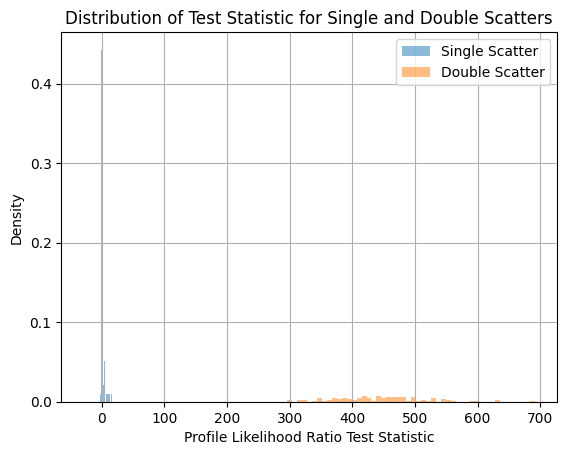

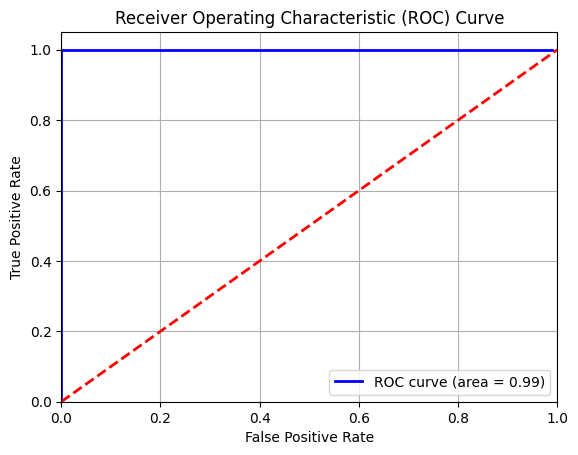

In [23]:
#Profile likelihood ratio test statistic
def profile_likelihood_ratio(signal, xy1=None, xy2=None, ratio=None):
    """Calculate the profile likelihood ratio test statistic for a given signal."""
    # Optimize under single scatter hypothesis
    single_params = single_scatter_optimizer(signal)
    single_loss = loss_function(single_params, signal)

    # Optimize under double scatter hypothesis
    double_params = double_scatter_optimizer(signal, xy1, xy2, ratio)
    double_loss = double_scatter_loss(double_params.x, signal)

    # Test statistic is 2*(single_loss - double_loss)
    test_statistic = 2 * (single_loss - double_loss)
    return test_statistic, single_params, double_params

#
#Is this actually chi squared?
#This has to do with Wilk's theorem
#
def calculate_chi2_statistics(num_iterations=1000, photons=10_000, distance=10, ratio=0.5):
    """Calculate chi2 statistics for single and double scatter signals, using the profile likelihood ratio test statistic."""
    single_stats = []
    double_stats = []
    for _ in range(num_iterations):
        single_signal = simulate_uniform_signals(1, photons)[0].squeeze()

        double_signal, xy1, xy2, ratio_out = simulate_double_signal_constrained_parameters(1, photons, distance, ratio)
        double_signal = double_signal[0].squeeze()
        xy1 = xy1[0:1]  # shape (2,)
        xy2 = xy2[0:1]  # shape (2,)
    
        single_stats.append(profile_likelihood_ratio(single_signal)[0])
        double_stats.append(profile_likelihood_ratio(double_signal, xy1, xy2, ratio_out)[0])

    #make histogram of the statistics
    plt.hist(single_stats, bins=50, alpha=0.5, label='Single Scatter', density=True)
    plt.hist(double_stats, bins=50, alpha=0.5, label='Double Scatter', density=True)
    plt.xlabel('Profile Likelihood Ratio Test Statistic')
    plt.ylabel('Density')
    plt.title('Distribution of Test Statistic for Single and Double Scatters')
    plt.legend()
    plt.grid()
    plt.show()
    return np.array(single_stats), np.array(double_stats)


def selection_operation(chi2_single, chi2_double, threshold):
    """Run selection on both arrays based on chi2 value, accepting values below the threshold
    and rejecting values at or above the threshold. Returns true positive rate and false positive rate.
    In the ideal case, all single scatters should be accepted and all double scatters should be rejected."""
    single_accepted = chi2_single < threshold
    double_accepted = chi2_double < threshold
    true_positive = np.sum(single_accepted) / len(chi2_single) #by formula TPR = TP / (TP + FN)
    false_positive = np.sum(double_accepted) / len(chi2_double) #by formula FPR = FP / (FP + TN)
    return true_positive, false_positive

def roc_curve(chi2_single, chi2_double):
    """Determine ROC curve, using as thresholds all unique statistic values from both arrays..
    Returns false positive rates, true positive rates, and thresholds."""

    thresholds = np.sort(np.unique(np.concatenate((chi2_single, chi2_double))))
    tprs = []
    fprs = []
    for threshold in thresholds:
        tpr, fpr = selection_operation(chi2_single, chi2_double, threshold)
        tprs.append(tpr)
        fprs.append(fpr)
    return np.array(fprs), np.array(tprs), thresholds

def plot_roc_curve(chi2_single, chi2_double):
    """Plot ROC curve for some chi2 datapoints"""
    fprs, tprs, thresholds = roc_curve(chi2_single, chi2_double)
    roc_auc = auc(fprs, tprs)
    
    plt.figure()
    plt.plot(fprs, tprs, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()


plot_roc_curve(*calculate_chi2_statistics(num_iterations=100, photons=10_000, distance=10, ratio=0.5))


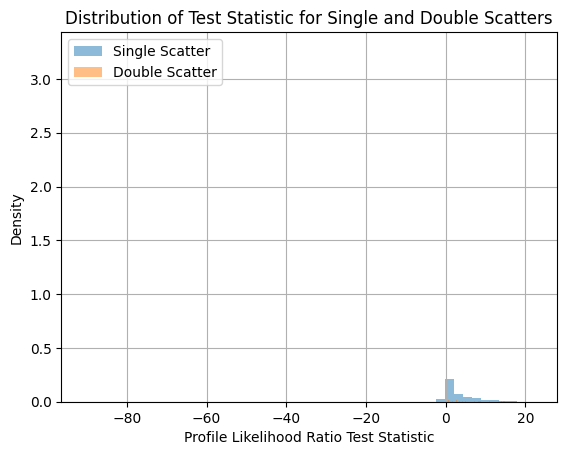

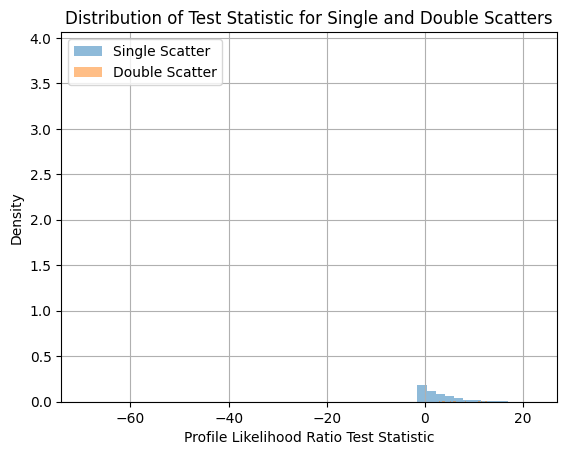

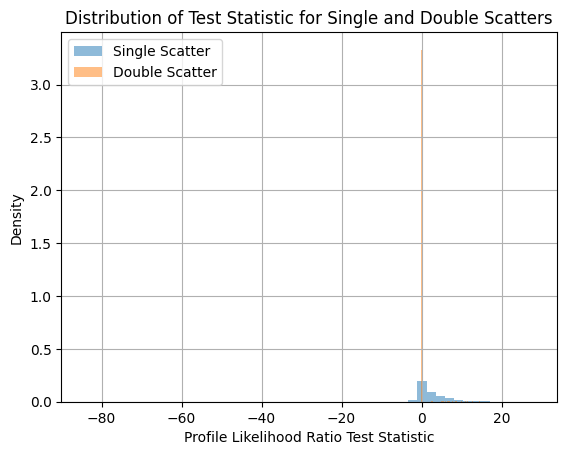

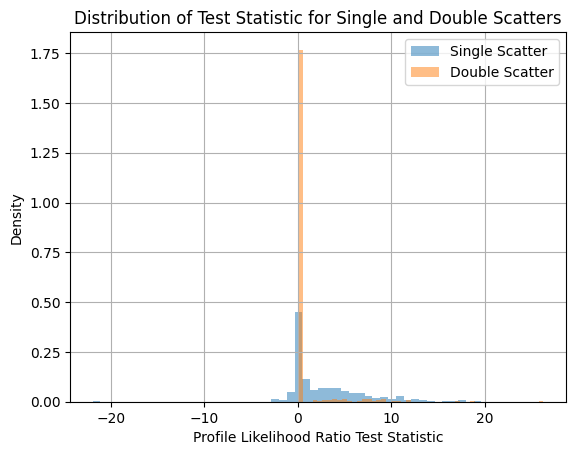

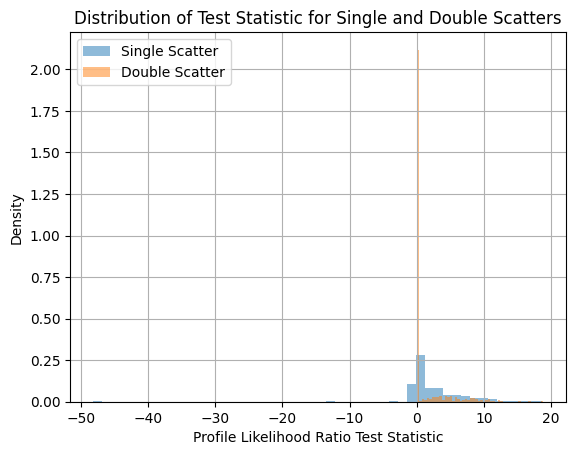

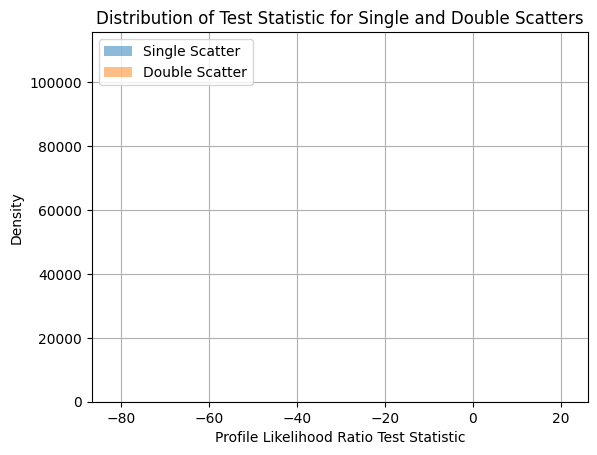

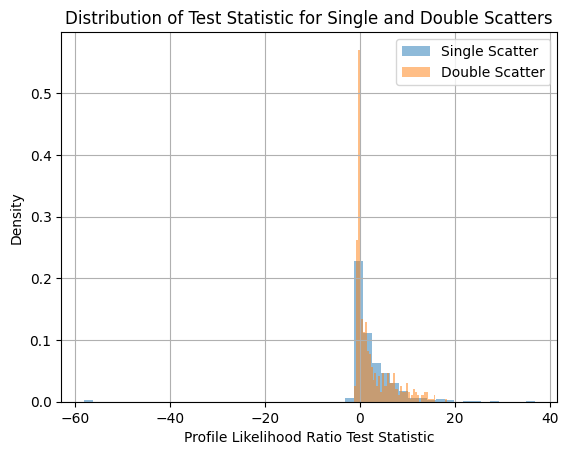

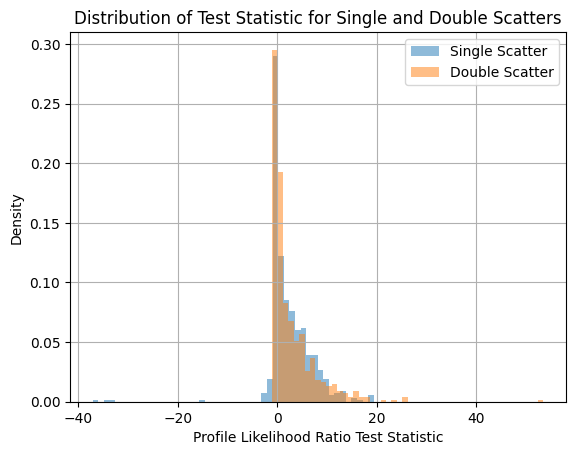

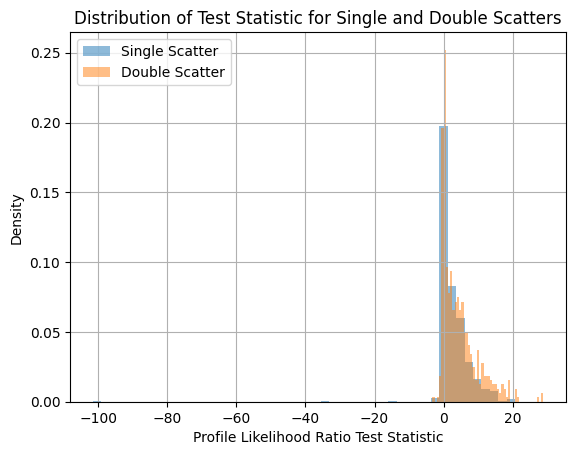

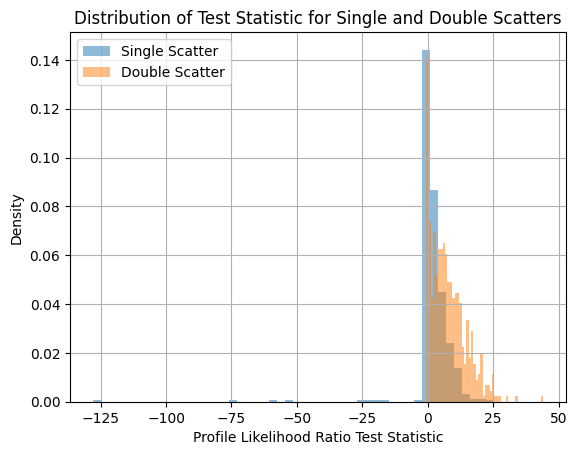

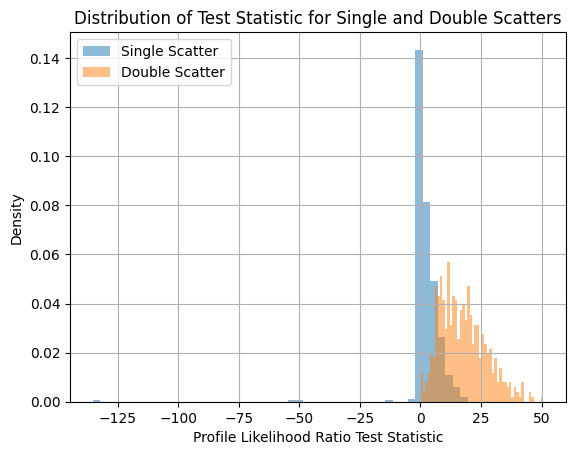

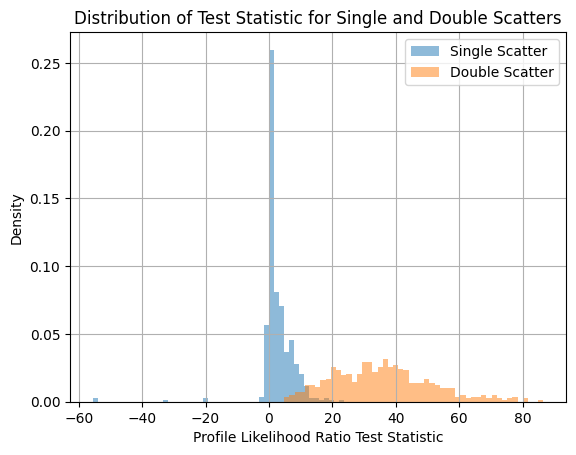

In [ ]:
def AUC(chi2_single, chi2_double):
    """Calculate the area under the ROC curve for given chi2 values"""
    fprs, tprs, thresholds = roc_curve(chi2_single, chi2_double)
    return auc(fprs, tprs)

def AUC_heatmap(distances, ratios, num_iterations=1000, photons=10_000):
    """Calculate AUC for a range of distances and ratios, and plot as heatmap"""
    auc_values = np.zeros((len(distances), len(ratios)))
    for i, distance in enumerate(distances):
        for j, ratio in enumerate(ratios):
            chi2_single, chi2_double = calculate_chi2_statistics(num_iterations, photons, distance, ratio)
            auc_values[i, j] = AUC(chi2_single, chi2_double)
    
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(auc_values, cmap='viridis', vmin=0.5, vmax=1.0)
    plt.colorbar(label='AUC')
    for i in range(len(distances)):
        for j in range(len(ratios)):
            plt.text(j + 0.5, i + 0.5, f'{auc_values[i, j]:.2f}',
                ha='center', va='center',
                color='white' if auc_values[i, j] < 0.75 else 'black',
                fontsize=8)
    plt.xticks(np.arange(len(ratios)) + 0.5, [f'{r:.2f}' for r in ratios])
    plt.yticks(np.arange(len(distances)) + 0.5, [f'{d:.0f}' for d in distances])
    plt.xlabel('Signal Ratio (ratio)')
    plt.ylabel('Distance between scatters (cm)')
    plt.title('AUC Heatmap for Double Scatter Discrimination')
    plt.show()

distances = np.linspace(0, 20, 5)  # Example distances from 0 to 20 cm
ratios = np.array([0.01, 0.02, 0.05, 0.1, 0.2, 0.5])  # Example ratios from 0.01 to 0.9
AUC_heatmap(distances, ratios, num_iterations=500, photons=10_000)

Since there is a persistence of false positives, now creating a database to sift through results

Found 2 events


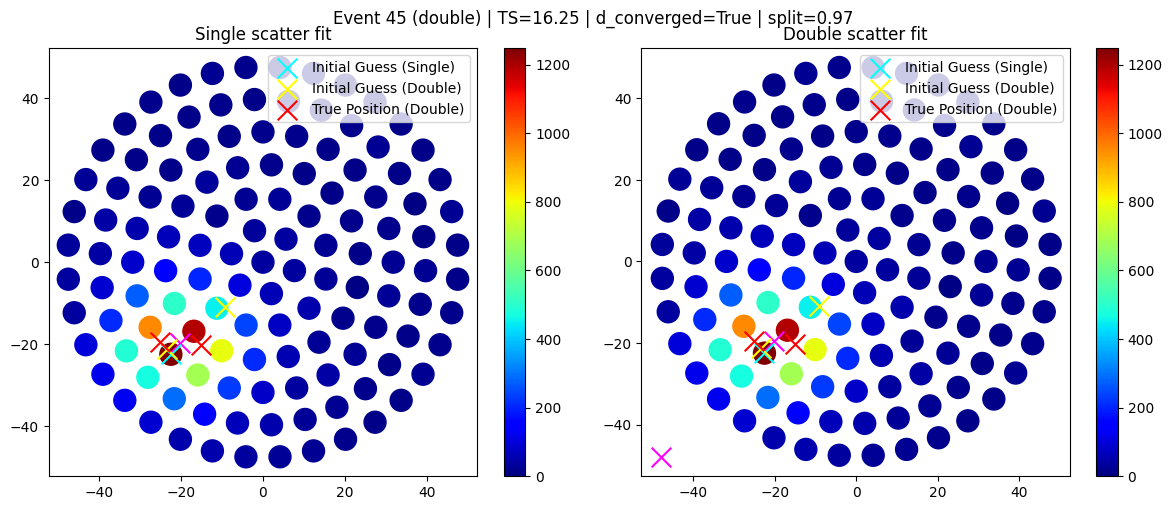

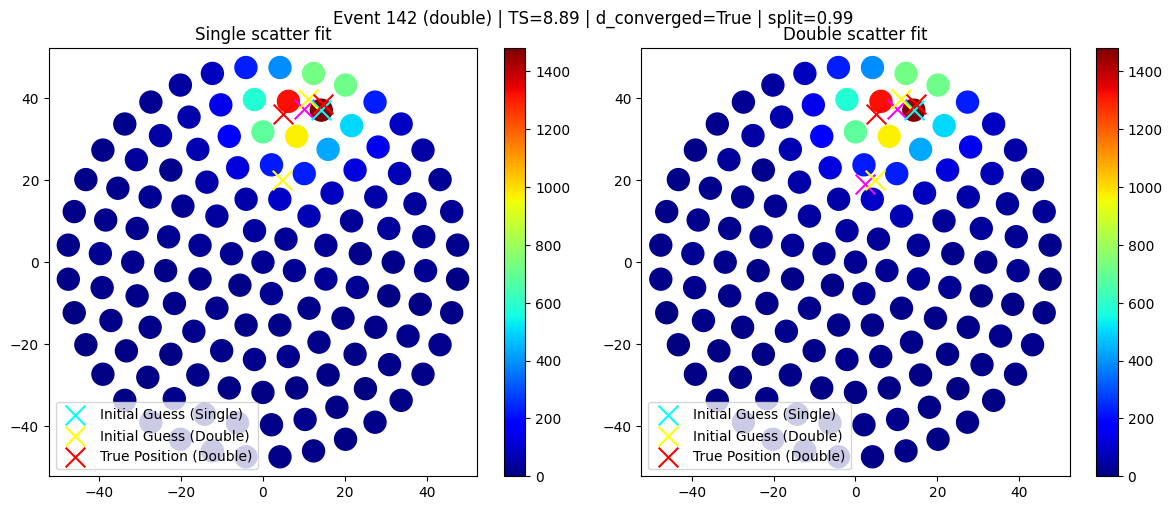

In [8]:
#Creating a database of signals with corresponding fits and plots

def build_ts_database(signals, label, xy1=None, xy2=None):
    """
    Run both fits on each signal and collect results into a DataFrame.
    label: 'single' or 'double' — what the signal truly is
    """
    records = []
    raw_signals = []

    for i, signal in enumerate(signals):
        test_statistic, single_params, double_result = profile_likelihood_ratio(signal)
        initial_guess, *_ = double_scatter_initial_guess(signal)
        records.append({
            "event_id":       i,
            "true_label":     label,
            "ts":             test_statistic,
            "ts_single_loss": loss_function(single_params, signal),
            "ts_double_loss": double_scatter_loss(double_result.x, signal),
            # Single scatter fit result
            "s_x":            single_params[0],
            "s_y":            single_params[1],
            # Double scatter fit result
            "d_x1":           double_result.x[0],
            "d_y1":           double_result.x[1],
            "d_x2":           double_result.x[2],
            "d_y2":           double_result.x[3],
            "d_split":        double_result.x[4],
            # Initial guess for single and double scatter fits
            "s_initial_x":    pmt_positions[np.argmax(signal)][0],
            "s_initial_y":    pmt_positions[np.argmax(signal)][1],
            "d_initial_x1":   initial_guess[0],
            "d_initial_y1":   initial_guess[1],
            "d_initial_x2":   initial_guess[2],
            "d_initial_y2":   initial_guess[3],
            "d_initial_split": initial_guess[4],
            #Original position parameters
            "d_true_x1": xy1[i, 0] if xy1 is not None else np.nan,
            "d_true_y1": xy1[i, 1] if xy1 is not None else np.nan,
            "d_true_x2": xy2[i, 0] if xy2 is not None else np.nan,
            "d_true_y2": xy2[i, 1] if xy2 is not None else np.nan,
            # Optimizer diagnostics
            "d_converged":    double_result.success,
            "d_nfev":         double_result.nfev,
        })
        raw_signals.append(signal)

    df = pd.DataFrame(records)
    return df, np.array(raw_signals)


# --- Build and save ---
single_signals, single_xy = simulate_uniform_signals(num_signals=200)
double_signals, double_xy1, double_xy2 = simulate_double_signal_constrained_parameters(num_signals=200, distance=10, ratio=0.5)

df_single, raw_single = build_ts_database(single_signals, label="single")
df_double, raw_double = build_ts_database(double_signals, label="double", xy1=double_xy1, xy2=double_xy2)

df_all = pd.concat([df_single, df_double], ignore_index=True)
df_all.to_csv("ts_database.csv", index=False)
np.savez("raw_signals.npz", single=raw_single, double=raw_double)

df = pd.read_csv("ts_database.csv")
raw = np.load("raw_signals.npz")

def get_signal(row):
    """Retrieve the raw signal array for a given DataFrame row."""
    array = raw[row["true_label"]]   # raw['single'] or raw['double']
    return array[row["event_id"]]

def inspect_ts_range(ts_min, ts_max, label=None):
    """Plot fits for all events whose TS falls in [ts_min, ts_max]."""
    mask = (df["ts"] >= ts_min) & (df["ts"] <= ts_max)
    if label:
        mask &= (df["true_label"] == label)
    
    matches = df[mask]
    print(f"Found {len(matches)} events")

    for _, row in matches.iterrows():
        signal = get_signal(row)
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        for ax, title, xs, ys in zip(
            axes,
            ["Single scatter fit", "Double scatter fit"],
            [[row["s_x"]], [row["d_x1"], row["d_x2"]]],
            [[row["s_y"]], [row["d_y1"], row["d_y2"]]],
        ):
            sc = ax.scatter(*pmt_positions.T, c=signal, cmap='jet', s=250, vmin=0)
            ax.scatter(xs, ys, c='magenta', marker='x', s=200, zorder=5)
            ax.scatter([row["s_initial_x"]], [row["s_initial_y"]], c='cyan', marker='x', s=200, zorder=5, label='Initial Guess (Single)')
            ax.scatter([row["d_initial_x1"], row["d_initial_x2"]], [row["d_initial_y1"], row["d_initial_y2"]], c='yellow', marker='x', s=200, zorder=5, label='Initial Guess (Double)')
            ax.scatter([row["d_true_x1"], row["d_true_x2"]], [row["d_true_y1"], row["d_true_y2"]], c='red', marker='x', s=200, zorder=5, label='True Position (Double)')
            ax.legend()
            ax.set_aspect('equal')
            ax.set_title(title)
            plt.colorbar(sc, ax=ax)

        plt.suptitle(
            f"Event {row['event_id']} ({row['true_label']}) | "
            f"TS={row['ts']:.2f} | "
            f"d_converged={row['d_converged']} | "
            f"split={row['d_split']:.2f}"
        )
        plt.tight_layout()
        plt.show()

# Example: look at single-scatter events with suspiciously high TS
inspect_ts_range(ts_min=5, ts_max=20, label="double")

Found 1 events

--- Event 177 (double) ---
  TS = 1.7139
  Single fit:  x=-25.57, y=-11.67  |  loss=-54224.3855
  Double fit:  x1=(-25.64, -11.71), x2=(-12.90, -4.93), split=0.99  |  loss=-54225.2425
  Double converged: True  |  nfev=90


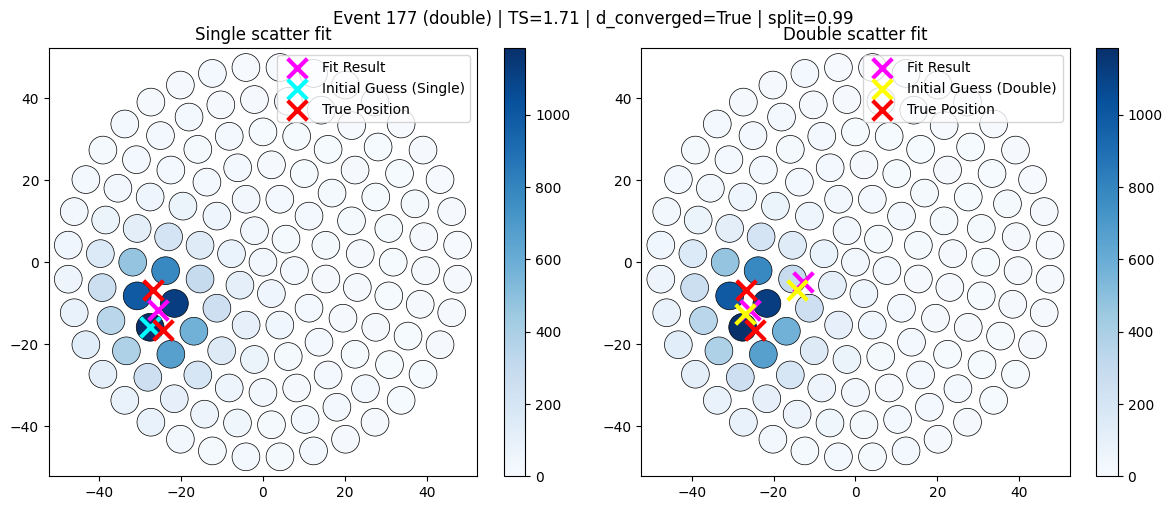

In [17]:
def inspect_ts_range(ts_min, ts_max, label=None):
    """Plot fits for all events whose TS falls in [ts_min, ts_max]."""
    mask = (df["ts"] >= ts_min) & (df["ts"] <= ts_max)
    if label:
        mask &= (df["true_label"] == label)
    
    matches = df[mask]
    print(f"Found {len(matches)} events")

    for _, row in matches.iterrows():
        signal = get_signal(row)
        
        # Print fit results
        print(f"\n--- Event {row['event_id']} ({row['true_label']}) ---")
        print(f"  TS = {row['ts']:.4f}")
        print(f"  Single fit:  x={row['s_x']:.2f}, y={row['s_y']:.2f}  |  loss={row['ts_single_loss']:.4f}")
        print(f"  Double fit:  x1=({row['d_x1']:.2f}, {row['d_y1']:.2f}), x2=({row['d_x2']:.2f}, {row['d_y2']:.2f}), split={row['d_split']:.2f}  |  loss={row['ts_double_loss']:.4f}")
        print(f"  Double converged: {row['d_converged']}  |  nfev={row['d_nfev']}")

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        for ax_idx, (ax, title, xs, ys) in enumerate(zip(
            axes,
            ["Single scatter fit", "Double scatter fit"],
            [[row["s_x"]], [row["d_x1"], row["d_x2"]]],
            [[row["s_y"]], [row["d_y1"], row["d_y2"]]],
        )):
            sc = ax.scatter(*pmt_positions.T, c=signal, cmap='Blues', s=400, vmin=0, edgecolors='black', linewidths=0.5)
            ax.scatter(xs, ys, c='magenta', marker='x', s=200, zorder=5, linewidths=3, label='Fit Result')
            if ax_idx == 0:
                ax.scatter([row["s_initial_x"]], [row["s_initial_y"]], c='cyan', marker='x', s=200, zorder=5, linewidths=3, label='Initial Guess (Single)')

            if ax_idx == 1:
                ax.scatter([row["d_initial_x1"], row["d_initial_x2"]],
                           [row["d_initial_y1"], row["d_initial_y2"]],
                           c='yellow', marker='x', s=200, zorder=5, linewidths=3, label='Initial Guess (Double)')

            if not np.isnan(row["d_true_x1"]):
                ax.scatter([row["d_true_x1"], row["d_true_x2"]],
                           [row["d_true_y1"], row["d_true_y2"]],
                           c='red', marker='x', s=200, zorder=5, linewidths=3, label='True Position')

            ax.legend()
            ax.set_aspect('equal')
            ax.set_title(title)
            plt.colorbar(sc, ax=ax)

        plt.suptitle(
            f"Event {row['event_id']} ({row['true_label']}) | "
            f"TS={row['ts']:.2f} | "
            f"d_converged={row['d_converged']} | "
            f"split={row['d_split']:.2f}"
        )
        plt.tight_layout()
        plt.show()

# --- Build and save ---
single_signals, single_xy = simulate_uniform_signals(num_signals=200)
double_signals, double_xy1, double_xy2 = simulate_double_signal_constrained_parameters(num_signals=200, distance=10, ratio=0.5)

df_single, raw_single = build_ts_database(single_signals, label="single")
df_double, raw_double = build_ts_database(double_signals, label="double", xy1=double_xy1, xy2=double_xy2)

df_all = pd.concat([df_single, df_double], ignore_index=True)
df_all.to_csv("ts_database.csv", index=False)
np.savez("raw_signals.npz", single=raw_single, double=raw_double)

df = pd.read_csv("ts_database.csv")
raw = np.load("raw_signals.npz")        

inspect_ts_range(ts_min=1, ts_max=20, label="double")

In [ ]:
# --- Build and save ---
single_signals, single_xy = simulate_uniform_signals(num_signals=200)
double_signals, double_xy1, double_xy2 = simulate_double_signal_constrained_parameters(num_signals=200, distance=10, ratio=0.5)

df_single, raw_single = build_ts_database(single_signals, label="single")
df_double, raw_double = build_ts_database(double_signals, label="double", xy1=double_xy1, xy2=double_xy2)

df_all = pd.concat([df_single, df_double], ignore_index=True)
df_all.to_csv("ts_database.csv", index=False)
np.savez("raw_signals.npz", single=raw_single, double=raw_double)

df = pd.read_csv("ts_database.csv")
raw = np.load("raw_signals.npz")        

inspect_ts_range(ts_min=1, ts_max=20, label="double")